In [1]:
import sys
sys.path.append("../src")

import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np

In [7]:
model = models.resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    4
)

model.load_state_dict(
    torch.load(
        "../models/resnet18_brain_tumor.pth",
        map_location="cpu"
    )
)

model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [3]:
from brisc_project.brisc import get_data_loader

test_loader, classes = get_data_loader(
    r"C:\Users\ccai2\Downloads\brain_tumor\brisc2025\classification_task\test",
    batch_size=1
)

image, label = next(iter(test_loader))

with torch.no_grad():
    output = model(image)
    prediction = output.argmax(dim=1)

print("Actual:", classes[label.item()])
print("Predicted:", classes[prediction.item()])

Actual: no_tumor
Predicted: no_tumor


In [8]:
correct_image = None
correct_label = None
correct_prediction = None

model.eval()

with torch.no_grad():
    for image, label in test_loader:
        output = model(image)
        prediction = output.argmax(dim=1)

        actual_class = classes[label.item()]
        predicted_class = classes[prediction.item()]

        if actual_class != "no_tumor" and actual_class == predicted_class:
            correct_image = image
            correct_label = label
            correct_prediction = prediction
            break

print("Actual:", classes[correct_label.item()])
print("Predicted:", classes[correct_prediction.item()])

Actual: meningioma
Predicted: meningioma


In [4]:
image, label = next(iter(test_loader))

In [6]:
torch.save(
    model.state_dict(),
    "../models/resnet18_brain_tumor.pth"
)

In [9]:
activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

target_layer = model.layer4[-1]

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

In [10]:
model.zero_grad()

output = model(correct_image)

class_idx = correct_prediction.item()
score = output[:, class_idx]

score.backward()

In [11]:
weights = gradients.mean(dim=(2, 3), keepdim=True)

cam = (weights * activations).sum(dim=1).squeeze()

cam = torch.relu(cam)

cam = cam - cam.min()
cam = cam / cam.max()

cam = cam.detach().numpy()

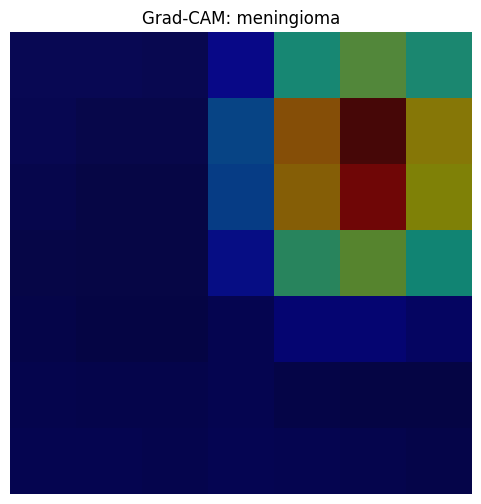

In [12]:
import matplotlib.pyplot as plt
import numpy as np

img = correct_image.squeeze().permute(1, 2, 0).numpy()

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.imshow(cam, cmap="jet", alpha=0.5)
plt.title(f"Grad-CAM: {classes[class_idx]}")
plt.axis("off")
plt.show()